In [8]:
#MUGISHA Frank Patrick 26RP01306

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("house_price_prediction_dataset.csv")
display(df.head(10))
display(df.info())
display(df.describe(include="all"))
print("Shape:",df.shape)

Shape: (125, 9)


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8
5,1006,850.0,3.0,3.0,2.1,15.93,0.0,Kigali City,150.2
6,1007,262.2,2.0,2.0,2.9,0.30,1.0,Musanze,198.7
7,1008,NaN,4.0,3.0,2.2,2.51,1.0,Huye,177.1
8,1009,85.0,3.0,2.0,4.3,0.56,0.0,Nyarugenge,112.2
9,1010,148.2,2.0,2.0,0.4,2.04,1.0,Huye,176.0


<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    str    
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 9.8 KB


None

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
count,125.000000,123.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124,124.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Huye,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
mean,1059.000000,134.808943,3.298387,3.016129,9.773387,5.652419,1.185484,NaN,173.254032
std,34.938887,133.300251,1.216284,1.202868,10.435564,8.701097,0.849361,NaN,127.372543
min,1001.000000,26.000000,1.000000,1.000000,0.400000,0.070000,0.000000,NaN,77.700000
25%,1028.000000,82.450000,2.000000,2.000000,3.175000,1.557500,1.000000,NaN,118.525000
50%,1058.000000,107.900000,3.000000,3.000000,6.650000,3.535000,1.000000,NaN,150.650000
75%,1089.000000,141.000000,4.000000,4.000000,12.125000,7.072500,2.000000,NaN,186.675000


In [9]:
#Missing values
display(df.isnull().sum().to_frame("Missing Values"))

,Missing Values
House_ID,0
Area_m2,2
Bedrooms,1
Bathrooms,1
House_Age_Years,1
Distance_to_City_km,1
Parking_Spaces,1
Neighborhood,1
House_Price_Million_RWF,1


Drop a row with missing target. Impute numeric predictors with the median and Neighborhood with the mode because only a small number of predictor values are missing.

In [10]:
#Detect and remove duplicate records. 
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates().copy()

Duplicates: 5


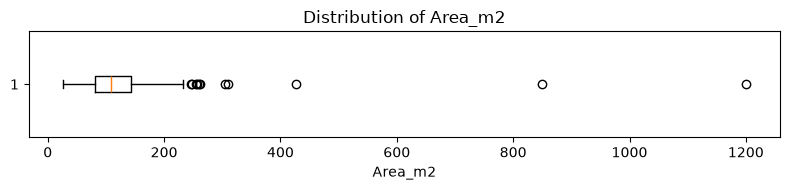

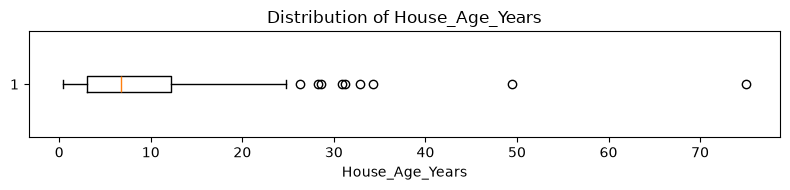

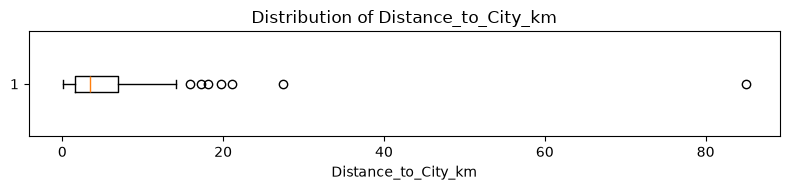

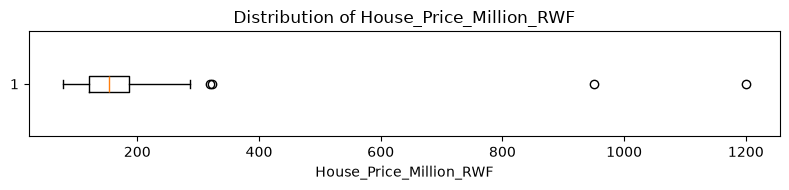

In [11]:
#Detect outliers or impossible values  with boxplots and the IQR rule
cols = ["Area_m2", "House_Age_Years", "Distance_to_City_km", "House_Price_Million_RWF"]

for col in cols:
    plt.figure(figsize=(8, 2))
    plt.boxplot(df[col].dropna(), orientation="horizontal")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

After IQR/boxplot inspection, remove House_ID 1006, 1019, 1034, 1048, 1073 and 1092 as exceptionally extreme/inconsistent records. Retain moderate but plausible outliers.

In [12]:
#Cleaned document
df=df.dropna(subset=["House_Price_Million_RWF"]).copy()
df=df[~df["House_ID"].isin([1006,1019,1034,1048,1073,1092])].copy()
numeric_features=["Area_m2","Bedrooms","Bathrooms","House_Age_Years","Distance_to_City_km","Parking_Spaces"]

for c in numeric_features: df[c]=df[c].fillna(df[c].median())
df["Neighborhood"]=df["Neighborhood"].fillna(df["Neighborhood"].mode()[0])
df.to_csv("house_price_prediction_cleaned.csv",index=False)
print(df.shape); display(df.isnull().sum())

(113, 9)


House_ID                   0
Area_m2                    0
Bedrooms                   0
Bathrooms                  0
House_Age_Years            0
Distance_to_City_km        0
Parking_Spaces             0
Neighborhood               0
House_Price_Million_RWF    0
dtype: int64

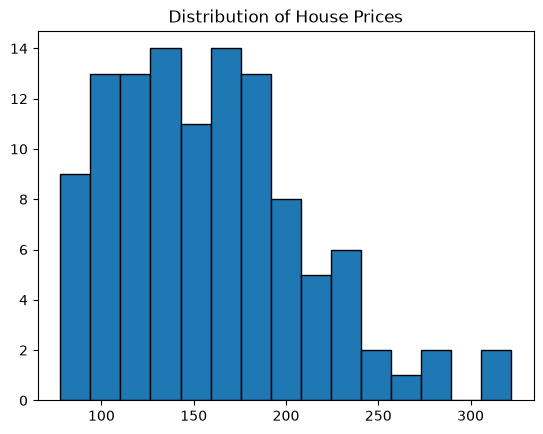

In [13]:
# Interpretation: Most cleaned prices are in the lower-to-middle range, with fewer high-price houses.
plt.hist(df["House_Price_Million_RWF"],bins=15,edgecolor="black");plt.title("Distribution of House Prices");plt.show()


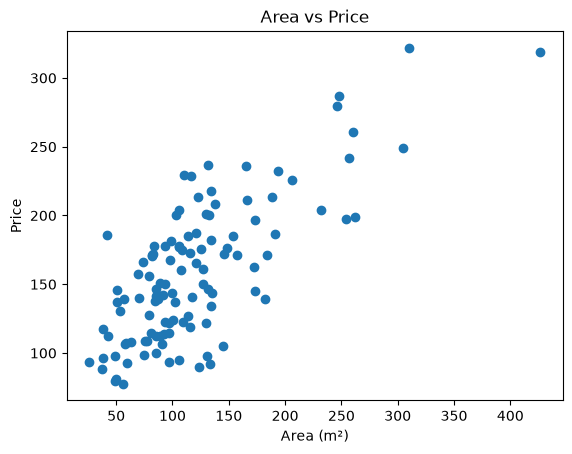

In [14]:
plt.scatter(df["Area_m2"],df["House_Price_Million_RWF"]);plt.xlabel("Area (m²)");plt.ylabel("Price");plt.title("Area vs Price");plt.show()
# Interpretation: Price generally increases as floor area increases.

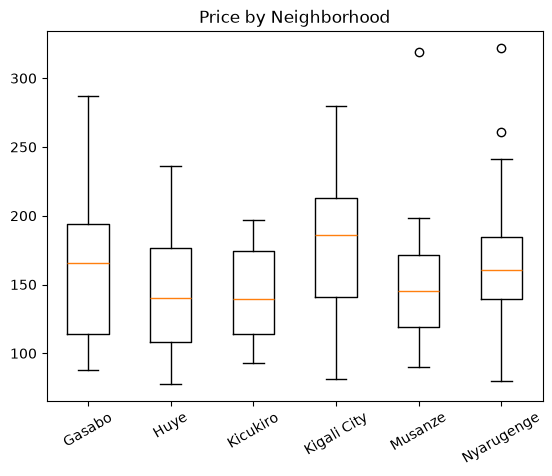

In [15]:
names=sorted(df["Neighborhood"].unique()); groups=[df.loc[df["Neighborhood"]==n,"House_Price_Million_RWF"] for n in names]
plt.boxplot(groups,tick_labels=names);plt.xticks(rotation=30);plt.title("Price by Neighborhood");plt.show()
# Interpretation: Price distributions differ across neighborhoods.

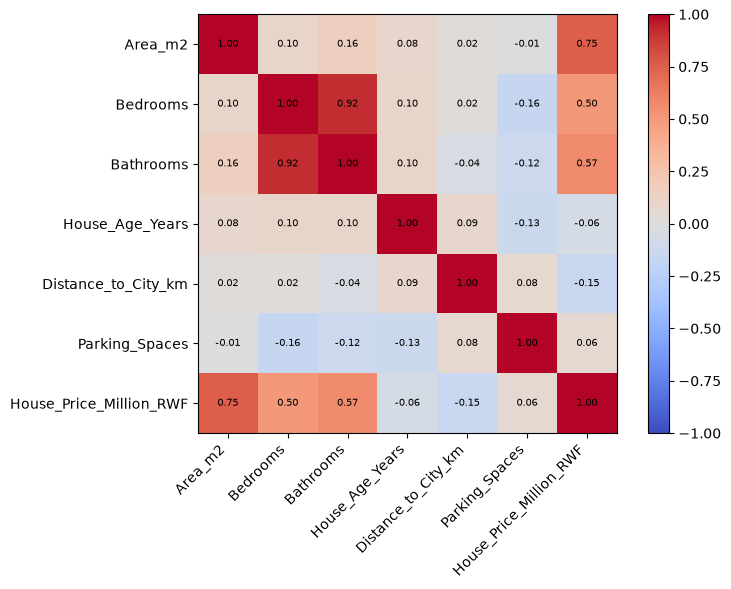

In [16]:
corr=df[numeric_features+["House_Price_Million_RWF"]].corr()
plt.figure(figsize=(8,6));im=plt.imshow(corr,vmin=-1,vmax=1,cmap="coolwarm");plt.colorbar(im);plt.xticks(range(len(corr)),corr.columns,rotation=45,ha="right");plt.yticks(range(len(corr)),corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)): plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.tight_layout();plt.show()
# Interpretation: Bedrooms and Bathrooms are strongly correlated.

### DECISIONS FOR CLEANING
| Problem | Where | Action | Reason |
|---|---|---|---|
| Duplicates | Full rows | Remove | Avoid bias |
| Missing target | Price | Drop row | Cannot train without target |
| Missing numeric | Predictors | Median impute | Robust and preserves rows |
| Missing category | Neighborhood | Mode impute | Suitable simple categorical treatment |
| Extreme anomalies | IDs 1006,1019,1034,1048,1073,1092 | Remove | Exceptionally extreme/inconsistent |
| Text category | Neighborhood | One-hot; drop first | Regression input and dummy trap |

In [22]:
df.to_csv("house_price_prediction_cleaned.csv", index=False)
 
print("CSV file saved successfully!")

CSV file saved successfully!


    REGRESSION AND MODEL TRAINING

In [26]:
import math
import pickle 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dataset = pd.read_csv("house_price_prediction_cleaned.csv")

dataset

features=numeric_features+["Neighborhood"]; target="House_Price_Million_RWF"
X=df[features];y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
preprocessor=ColumnTransformer([("num",SimpleImputer(strategy="median"),numeric_features),("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(drop="first",handle_unknown="ignore"))]),["Neighborhood"])])
model=Pipeline([("preprocessor",preprocessor),("regressor",LinearRegression())])
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Area_m2','Bedrooms','Bathrooms',...,'Distance_to_City_km', 'Parking_Spaces','Neighborhood']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [27]:
feature_names=model.named_steps["preprocessor"].get_feature_names_out()
print("Intercept:",model.named_steps["regressor"].intercept_)
display(pd.DataFrame({"Variable":feature_names,"Coefficient":model.named_steps["regressor"].coef_}))

Intercept: 29.528657513473746


,Variable,Coefficient
0,num__Area_m2,0.560317
1,num__Bedrooms,3.710935
2,num__Bathrooms,19.013659
3,num__House_Age_Years,-0.864319
4,num__Distance_to_City_km,-0.984798
5,num__Parking_Spaces,6.121449
6,cat__Neighborhood_Huye,-11.863221
7,cat__Neighborhood_Kicukiro,-11.816313
8,cat__Neighborhood_Kigali City,15.598600
9,cat__Neighborhood_Musanze,-17.231320


In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numeric_X=df[numeric_features]
display(numeric_X.corr())
display(pd.DataFrame({"Variable":numeric_features,"VIF":[variance_inflation_factor(numeric_X.values,i) for i in range(len(numeric_features))]}))

,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces
Area_m2,1.000000,0.100124,0.155562,0.082813,0.019543,-0.007868
Bedrooms,0.100124,1.000000,0.921282,0.096887,0.016599,-0.155084
Bathrooms,0.155562,0.921282,1.000000,0.099321,-0.043608,-0.122620
House_Age_Years,0.082813,0.096887,0.099321,1.000000,0.093212,-0.128925
Distance_to_City_km,0.019543,0.016599,-0.043608,0.093212,1.000000,0.076993
Parking_Spaces,-0.007868,-0.155084,-0.122620,-0.128925,0.076993,1.000000


,Variable,VIF
0,Area_m2,4.023023
1,Bedrooms,56.666668
2,Bathrooms,54.644014
3,House_Age_Years,2.143758
4,Distance_to_City_km,2.052041
5,Parking_Spaces,2.514679


In [29]:
def adjusted_r2(r2,n,p): return 1-(1-r2)*(n-1)/(n-p-1)
p=len(feature_names); rows=[]
for name,xx,yy in [("Training",X_train,y_train),("Testing",X_test,y_test)]:
    pr=model.predict(xx);r2=r2_score(yy,pr);rows.append([name,r2,adjusted_r2(r2,len(yy),p),mean_absolute_error(yy,pr),math.sqrt(mean_squared_error(yy,pr))])
display(pd.DataFrame(rows,columns=["Dataset","R²","Adjusted R²","MAE","RMSE"]))

,Dataset,R²,Adjusted R²,MAE,RMSE
0,Training,0.881241,0.864493,14.493915,17.716925
1,Testing,0.787919,0.575839,18.375411,22.936607


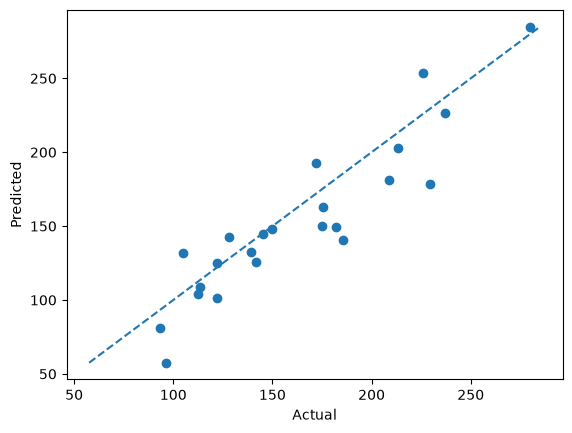

In [30]:
y_pred=model.predict(X_test);plt.scatter(y_test,y_pred);mn=min(y_test.min(),y_pred.min());mx=max(y_test.max(),y_pred.max());plt.plot([mn,mx],[mn,mx],"--");plt.xlabel("Actual");plt.ylabel("Predicted");plt.show()

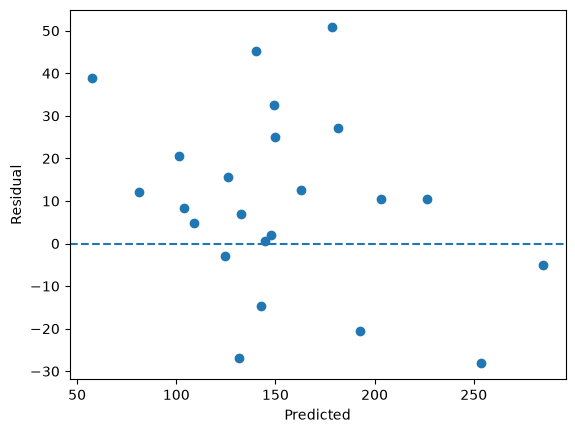

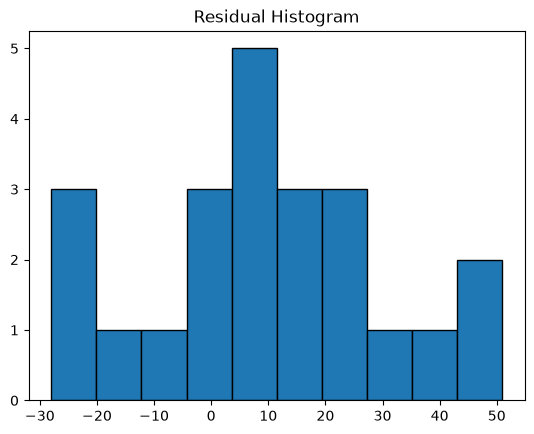

In [31]:
residuals=y_test-y_pred;plt.scatter(y_pred,residuals);plt.axhline(0,linestyle="--");plt.xlabel("Predicted");plt.ylabel("Residual");plt.show()
plt.hist(residuals,bins=10,edgecolor="black");plt.title("Residual Histogram");plt.show()

In [33]:
filename = "house_price_model.sav"
pickle.dump(model, open(filename, "wb"))

print("Model saved as:", filename)

Model saved as: house_price_model.sav


In [34]:
loaded_model = pickle.load(open("house_price_model.sav", "rb"))
print("Saved Model loaded done")

Saved Model loaded done


In [44]:
new_house = ({"Area_m2":300.0,"Bedrooms":4,"Bathrooms":3,"House_Age_Years":8.0,"Distance_to_City_km":8.0,"Parking_Spaces":3,"Neighborhood":"Gasabo"})
new_house=pd.DataFrame([new_house])
print(f"Predicted price: {loaded_model.predict(new_house)[0]:.2f} million RWF")

Predicted price: 273.08 million RWF
